# 优化

## 一个简单的问题

一个非常简单的问题，如何用最少的材料做一个容积为1m³的圆柱形容器？在把圆柱形容器简化为等厚的金属板并忽略接头的成本和材料耗损可以把问题描述为：一个圆柱体容器，在容积为1m³的条件下，表面积最小，应该如何选择尺寸？

![圆柱桶问题](imgs/bucket.png)

这个问题的对象（系统）非常简单，是一个静态对象，可以用两个参数来描述，分别是底面半径$r$和高度$h$。

$S_p = \{r, h\}$

我们要问的问题或者说要求解的问题是一个最小化的问题，当然难点在于还有一个约束。

$$ \arg\min_{S_p} A \quad \text{s.t.} \quad V=1 $$

通过简单的几何知识，有如下数学模型：

$$ \begin{cases} V = \pi r^2 h \\ A = 2\pi r h + 2\pi r^2 \end{cases} $$

## 符号求解

### 简单问题简单解

这个题目相当简单，在约束关系$V=1$中可以求解得到$h=\frac{1}{\pi r^2}$，代入$A$的表达式中，可以得到：

$$ A = 2\pi r \frac{1}{\pi r^2} + 2\pi r^2 = \frac{2}{r} + 2\pi r^2 $$

这是一个二次函数，类似于一个碗，最小值点很容易通过求解方程$\frac{dA}{dr}=0$得到。

$$ r_{min} = \sqrt[3]{\frac{1}{2\pi}} \approx 0.5419 $$

对应的$h_{min}$自然可以得到。

$$ h_{min} = \frac{1}{\pi r_{min}^2} = 2 \sqrt[3]{\frac{1}{2\pi}} = 2r_{min} \approx 1.0839 $$

### 使用 SymPy 提升难度

那我们非要用Python做怎么整呢？`sympy`符号运算库还是很好用的。

In [1]:
import sympy as sp
from IPython.display import display

# 定义符号变量
r, h = sp.symbols('r h', positive=True) # positive=True 保证 r, h > 0
pi = sp.pi

# 定义体积和面积的表达式
V = pi * r**2 * h
A = 2 * pi * r * h + 2 * pi * r**2

# 定义体积为1的约束
constraint = sp.Eq(V, 1)
print("约束条件:")
display(constraint)

# 从约束中求解 h
h_r = sp.solve(constraint, h)[0]
print("\nh(r) 表达式:")
display(sp.Eq(sp.Symbol('h'), h_r))

# 将 h(r) 代入面积公式
A_r = A.subs(h, h_r)
print("\nA(r) 表达式:")
display(sp.Eq(sp.Symbol('A'), A_r))

# 对 A(r) 求导
dA_dr = sp.diff(A_r, r)
print("\ndA/dr 表达式:")
display(dA_dr)

# 求解导数为0的点，即极值点
r_min_expr = sp.solve(dA_dr, r)[0]
print(f"\n半径的最优解 (符号): r_min = {r_min_expr}")
print(f"半径的最优解 (数值): r_min ≈ {r_min_expr.evalf()}")

# 验证二阶导数大于0，确保是最小值点
d2A_dr2 = sp.diff(dA_dr, r)
second_derivative_val = d2A_dr2.subs(r, r_min_expr).evalf()
print(f"\n二阶导数值: {second_derivative_val}")
assert second_derivative_val > 0
print("二阶导数 > 0, 确认是最小值点。")

# 计算对应的 h_min
h_min_expr = h_r.subs(r, r_min_expr)
print(f"\n高度的最优解 (符号): h_min = {h_min_expr}")
print(f"高度的最优解 (数值): h_min ≈ {h_min_expr.evalf()}")

print(f"\n结论: h_min / r_min = {sp.simplify(h_min_expr / r_min_expr)}")

约束条件:


Eq(pi*h*r**2, 1)


h(r) 表达式:


Eq(h, 1/(pi*r**2))


A(r) 表达式:


Eq(A, 2*pi*r**2 + 2/r)


dA/dr 表达式:


4*pi*r - 2/r**2


半径的最优解 (符号): r_min = 2**(2/3)/(2*pi**(1/3))
半径的最优解 (数值): r_min ≈ 0.541926070139289

二阶导数值: 37.6991118430775
二阶导数 > 0, 确认是最小值点。

高度的最优解 (符号): h_min = 2**(2/3)/pi**(1/3)
高度的最优解 (数值): h_min ≈ 1.08385214027858

结论: h_min / r_min = 2


### Lagrange multiplier a.k.a. 拉格朗日乘子法

当然，对于约束优化问题，还有一个常用的方式就是拉格朗日乘子法。

$$ \arg\min_{x} f(x) \quad \text{s.t.} \quad g(x)=0 $$

我们利用拉格朗日乘子$\lambda$把问题写为无约束优化：

$$ \arg\min_{x} f(x) + \lambda g(x) $$

我们非常暴力地把约束条件和优化目标写在一起构成一个新的函数：

$$ L(r, h, \lambda) = A(r, h) + \lambda [V(r, h) - 1] $$

然后求解方程组：

$$ \begin{cases} \frac{\partial L}{\partial r} = 0 \\ \frac{\partial L}{\partial h} = 0 \\ \frac{\partial L}{\partial \lambda} = 0 \end{cases} $$

In [3]:
# 使用拉格朗日乘子法
lambda_ = sp.Symbol('lambda') # lambda是Python关键字，加个下划线

# 1. 定义拉格朗日函数
L = A + lambda_ * (V - 1)
print("拉格朗日函数 L(r, h, lambda):")
display(L)

# 2. 求解偏导数为0的方程组
grad_L = [sp.diff(L, var) for var in (r, h, lambda_)]
print("\n方程组 (偏导数=0):")
display(grad_L)

result = sp.solve(grad_L, [r, h, lambda_], dict=True)

# 筛选出r和h为正实数的解
positive_real_solution = None
for sol in result:
    if sol[r].is_real and sol[r] > 0 and sol[h].is_real and sol[h] > 0:
        positive_real_solution = sol
        break

print("\n求解结果:")
if positive_real_solution:
    for key, value in positive_real_solution.items():
        print(f"  {key}: {value} ≈ {value.evalf()}")
else:
    print("未找到正实数解。")


拉格朗日函数 L(r, h, lambda):


2*pi*h*r + lambda*(pi*h*r**2 - 1) + 2*pi*r**2


方程组 (偏导数=0):


[2*pi*h*lambda*r + 2*pi*h + 4*pi*r, pi*lambda*r**2 + 2*pi*r, pi*h*r**2 - 1]


求解结果:
  h: 2**(2/3)/pi**(1/3) ≈ 1.08385214027858
  lambda: -2*2**(1/3)*pi**(1/3) ≈ -3.69054029728806
  r: 2**(2/3)/(2*pi**(1/3)) ≈ 0.541926070139289


## 交互式演示

我们可以利用`ipywidgets`和`matplotlib`来创建一个交互式界面，模拟[原文](<https://www.windtunnel.cn/posts/matlab/optimization/optimization-001/>)中的MATLAB App。通过拖动滑块来调节容器的底面半径，界面上会同步显示容器的高度、表面积以及对应的曲线。

![MATLAB App 界面](imgs/bucketopt.png)
![曲线图](imgs/curve.png)

FloatSlider(value=0.54, description='半径 r', max=2.0, min=0.1, step=0.01)

Output()

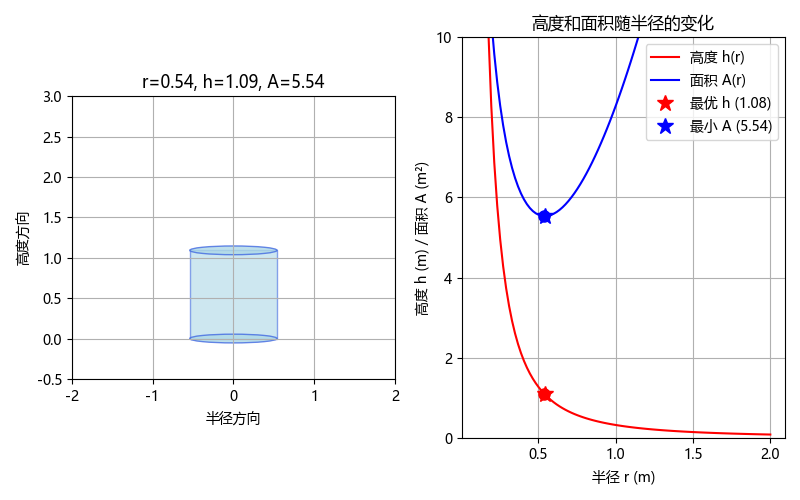

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Ellipse, Rectangle

# 1. 只创建一次图表和坐标轴
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))

# 2. 定义一个函数来更新图表内容
def update_plot(r):
    # 在每次更新前清除之前的绘图内容
    ax1.clear()
    ax2.clear()

    if r == 0:
        r = 1e-9 # 避免除以零
        
    # 计算 h 和 A
    h = 1 / (np.pi * r**2)
    A = 2 / r + 2 * np.pi * r**2
    
    # --- 左图：圆柱体形状 ---
    ax1.set_title(f'r={r:.2f}, h={h:.2f}, A={A:.2f}')
    rect = Rectangle((-r, 0), 2*r, h, edgecolor='royalblue', facecolor='lightblue', alpha=0.6)
    ax1.add_patch(rect)
    top_ellipse = Ellipse((0, h), 2*r, 0.2*r, edgecolor='royalblue', facecolor='lightblue', alpha=0.8)
    bottom_ellipse = Ellipse((0, 0), 2*r, 0.2*r, edgecolor='royalblue', facecolor='lightblue', alpha=0.8)
    ax1.add_patch(top_ellipse)
    ax1.add_patch(bottom_ellipse)
    ax1.set_xlim(-2, 2)
    ax1.set_ylim(-0.5, 3)
    ax1.set_aspect('equal', adjustable='box')
    ax1.set_xlabel('Radius Direction')
    ax1.set_ylabel('Height Direction')
    ax1.grid(True)

    # --- 右图：曲线 ---
    r_vals = np.linspace(0.1, 2, 100)
    h_vals = 1 / (np.pi * r_vals**2)
    A_vals = 2 / r_vals + 2 * np.pi * r_vals**2
    ax2.plot(r_vals, h_vals, 'r-', label='Height h(r)')
    ax2.plot(r_vals, A_vals, 'b-', label='Area A(r)')
    
    ax2.plot(r, h, 'ro', markersize=8)
    ax2.plot(r, A, 'bo', markersize=8)
    
    r_opt = (1 / (2 * np.pi))**(1/3)
    h_opt = 2 * r_opt
    A_opt = 2 / r_opt + 2 * np.pi * r_opt**2
    ax2.plot(r_opt, h_opt, 'r*', markersize=12, label=f'Optimal h ({h_opt:.2f})')
    ax2.plot(r_opt, A_opt, 'b*', markersize=12, label=f'Minimum A ({A_opt:.2f})')
    
    ax2.set_xlabel('Radius r (m)')
    ax2.set_ylabel('Height h (m) / Area A (m²)')
    ax2.set_title('Height and Area vs. Radius')
    ax2.legend()
    ax2.grid(True)
    ax2.set_ylim(0, 10)
    
    fig.tight_layout()

# 3. 创建滑块控件
r_slider = widgets.FloatSlider(min=0.1, max=2.0, step=0.01, value=0.54, description='半径 r', continuous_update=True)

# 4. 使用 interactive_output 将滑块和更新函数连接起来
out = widgets.interactive_output(update_plot, {'r': r_slider})

# 5. 显示滑块和图表
# HBox 将滑块和图表并排显示，VBox 会垂直显示
# 这里我们让滑块在上方，图表在下方
display(r_slider, out)

拖动半径滑块，看看当半径变得非常大后，容器的高度会变得非常小，而表面积会变得非常大。

![半径很大时的情形](imgs/flat.png)

## 模型问题

这么简单的问题，为什么要纠结？通过这个例子，我们可以窥见目前科学和工程技术研究中解决问题的基本思路：**建模**。

> **模型**：如果研究者 $B$ 用对象 $A^*$ 来解决对象 $A$ 的某个问题，则称 $A^*$ 为 $A$ 的模型。

这里的定义是一个一般的形式定义，使用的也是一般的用语。这里面，研究者 $B$ 就是建模的主体，而某个问题就是特指的特定问题，而非是泛化的问题，通常是分析、设计、控制、优化等。

而关于系统 $A$ 的模型 $A^*$，则挺有意思的：

-   模型 $A^*$ 是关于系统 $A$ 仅仅对解决特定问题有用的简化描述；
-   模型并非总是越复杂越好，恰恰相反，最佳模型是 1）符合目的（解决问题）的 2）最简单模型；
-   简化是建立模型的基本手段；
-   解决具体问题，总是从最简单的模型出发，逐步增加复杂度，直到模型满足解决该问题的要求。

通常，会采用一个称为 $\{S, Q, M\}$ 的元组来描述一个模型，其中 $S$ 是系统，$Q$ 是问题，$M$ 是数学描述。

$$ A^* = \{S, Q, M\} $$

对我们上面的对象，毫无疑问，$Q$ 是一个优化问题，也就是 $Q = \arg\min_{S_p} A$。而这里 $S$ 的数值表达形式：$S_p$，包含了简化的描述系统 $S$ 的参数，也就是 $S_p = \{r, h\}$。

而 $M$，则是 $S$ 和 $Q$ 的数学描述，也就是 $M = \{V, A\}$。

对于简单的优化问题，我们可以采用上面的符号推导的方式来进行求解，对于问题中的约束条件，则可以采用拉格朗日乘子法来进行求解。

对于更加复杂（$S$ 复杂、$Q$ 复杂、$M$ 复杂或者多个条件复杂）的问题，则需要采用更加复杂的优化算法，比如牛顿法、拟牛顿法、共轭梯度法、内点法、外点法等经典方法；或者采用智能优化算法，比如遗传算法、粒子群算法等。